# Gate Synthesis — syntesis_1_2\n\nTest dei gate definiti in `syntesis_1_2.py` usando Bloqade/squin.

In [1]:
import sys, os, importlib
sys.path.insert(0, os.path.dirname(os.path.abspath("syntesis_1_2.py")))

import gate_syntesis
importlib.reload(gate_syntesis)

import numpy as np
from qiskit.synthesis import gridsynth_rz
import gate_syntesis
importlib.reload(gate_syntesis)
from gate_syntesis import *
from bloqade import squin, tsim
from bloqade.types import Qubit
from kirin.dialects.ilist import IList
from typing import Any

Register = IList[Qubit, Any]

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Test gate a 1 qubit: X, Y, Z

In [2]:
@squin.kernel
def test_single_qubit_gates():
    qubits = squin.qalloc(1)
    X_gate(qubits[0])
    Y_gate(qubits[0])
    Z_gate(qubits[0])

tsim.Circuit(test_single_qubit_gates).diagram()

## Test gate a 2 qubit: CZ, SWAP

In [3]:
@squin.kernel
def test_two_qubit_gates():
    qubits = squin.qalloc(2)
    CZ_gate(qubits[0], qubits[1])
    SWAP_gate(qubits[0], qubits[1])

tsim.Circuit(test_two_qubit_gates).diagram()

## Test Toffoli (CCX) — gate a 3 qubit

In [4]:
@squin.kernel
def test_toffoli():
    qubits = squin.qalloc(3)
    Toffoli_gate(qubits[0], qubits[1], qubits[2])

tsim.Circuit(test_toffoli).diagram()

In [5]:
rz3 = Rz_gate(3)  # crea il kernel fuori da squin

@squin.kernel
def test_rz():
    qubits = squin.qalloc(1)
    rz3(qubits[0])

tsim.Circuit(test_rz).diagram(width=1200)

In [6]:
N_VALUES = range(8)
PART2_EPSILON = 1e-4

part2_circuits = {}
part2_sequences = {}

for n in N_VALUES:
    theta = np.pi / (2 ** n)
    circ = gridsynth_rz(theta, epsilon=PART2_EPSILON)
    sequence = gate_sequence_from_circuit(circ)

    part2_circuits[n] = circ
    part2_sequences[n] = sequence

    t_count = t_count_from_sequence(sequence)
    clifford_count = len(sequence) - t_count
    print(f"n={n}: T-count={t_count}, Clifford-count={clifford_count}")

n=0: T-count=0, Clifford-count=2
n=1: T-count=0, Clifford-count=1
n=2: T-count=1, Clifford-count=0
n=3: T-count=45, Clifford-count=67
n=4: T-count=43, Clifford-count=65
n=5: T-count=36, Clifford-count=54
n=6: T-count=41, Clifford-count=65
n=7: T-count=41, Clifford-count=62


,n,logical_T_count,postselection_success_probability_exact,dropout_probability_exact
0,0,0,1.000000e+00,0.0
1,1,0,1.000000e+00,0.0
2,2,1,5.000000e-01,0.5
3,3,45,2.842171e-14,1.0
4,4,43,1.136868e-13,1.0
5,5,36,1.455192e-11,1.0
6,6,41,4.547474e-13,1.0
7,7,41,4.547474e-13,1.0


,n,logical_T_count,shots,dropout_rate_estimated
0,0,0,0,0.000
1,1,0,0,0.000
2,2,1,200,0.485


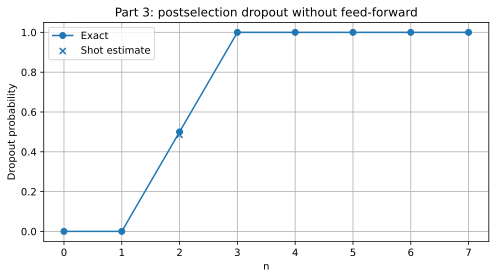

In [7]:
# ============================================================
# Part 3 — Postselection dropout without feed-forward correction
# ============================================================

import os, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bloqade.pyqrack import StackMemorySimulator

sys.path.insert(0, os.path.dirname(os.path.abspath("syntesis_1_2.py")))

import gate_syntesis; importlib.reload(gate_syntesis)
from gate_syntesis import make_postselected_dropout_kernel, t_count_from_sequence

N_VALUES      = globals().get("N_VALUES",      range(51))
PART2_EPSILON = globals().get("PART2_EPSILON", 1e-10)
RESULTS_DIR   = globals().get("RESULTS_DIR",   "results")

if "part2_circuits" not in globals() or "part2_sequences" not in globals():
    import postselection; importlib.reload(postselection)
    part2_circuits, part2_sequences = postselection.ensure_part2_results(N_VALUES, PART2_EPSILON)

# --- Exact dropout probabilities ---
rows = []
for n in N_VALUES:
    t = t_count_from_sequence(part2_sequences[n])
    rows.append({"n": n, "logical_T_count": t,
                 "postselection_success_probability_exact": 2**-t,
                 "dropout_probability_exact": 1 - 2**-t})
df_exact = pd.DataFrame(rows)
display(df_exact)

# --- Shot-based estimates (only for small T-count) ---
DROPOUT_SIM_SHOTS     = 200
MAX_SIMULATED_T_COUNT = 2

sim_rows = []
for n in N_VALUES:
    t = t_count_from_sequence(part2_sequences[n])
    if t > MAX_SIMULATED_T_COUNT:
        continue
    if t == 0:
        sim_rows.append({"n": n, "logical_T_count": t, "shots": 0, "dropout_rate_estimated": 0.0})
        continue
    kernel   = make_postselected_dropout_kernel(part2_sequences[n])
    task     = StackMemorySimulator(min_qubits=1 + t).task(kernel)
    dropouts = sum(int(task.run()) for _ in range(DROPOUT_SIM_SHOTS))
    sim_rows.append({"n": n, "logical_T_count": t,
                     "shots": DROPOUT_SIM_SHOTS, "dropout_rate_estimated": dropouts / DROPOUT_SIM_SHOTS})
df_sim = pd.DataFrame(sim_rows)
display(df_sim)

# --- Plot ---
os.makedirs(RESULTS_DIR, exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_exact["n"], df_exact["dropout_probability_exact"], marker="o", label="Exact")
if not df_sim.empty:
    est = df_sim[df_sim["shots"] > 0]
    ax.scatter(est["n"], est["dropout_rate_estimated"], marker="x", label="Shot estimate")
ax.set(xlabel="n", ylabel="Dropout probability",
       title="Part 3: postselection dropout without feed-forward",
       ylim=(-0.05, 1.05))
ax.set_xticks(df_exact["n"])
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "part3_postselection_dropout_probability.png"), dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# ============================================================
# Part 4 - Simulate one synthesized Rz sequence on Steane [[7,1,3]]
# ============================================================

import os
import sys
import importlib

from bloqade import squin, tsim

sys.path.insert(0, os.getcwd())

import gate_syntesis
import gate_syntesis_helpers

importlib.reload(gate_syntesis)
importlib.reload(gate_syntesis_helpers)

from gate_syntesis import (
    Steane_zero_logical_graph,
    Steane_magic_state_logical,
    Steane_apply_logical_gate_sequence,
)

from gate_syntesis_helpers import t_count_from_sequence


PART4_N = 2

part4_sequence = tuple(part2_sequences[PART4_N])
part4_t_count = t_count_from_sequence(part4_sequence)

print(f"Part 4 logical simulation for n={PART4_N}")
print(f"sequence = {' '.join(part4_sequence).upper()}")
print(f"T-count = {part4_t_count}")


@squin.kernel
def part4_steane_rz_demo():
    data_block = Steane_zero_logical_graph()

    # n=2 with epsilon=1e-4 has exactly one T gate,
    # so one logical magic-state ancilla block is enough.
    magic0 = Steane_magic_state_logical()

    Steane_apply_logical_gate_sequence(
        data_block,
        [magic0],
        part4_sequence,
    )


tsim.Circuit(part4_steane_rz_demo).diagram()


Part 4 logical simulation for n=2
sequence = T
T-count = 1


Simulating Part 4 n=0, T-count=0, shots=5
Simulating Part 4 n=1, T-count=0, shots=5
Simulating Part 4 n=2, T-count=1, shots=5
Simulating Part 4 n=3, T-count=45, shots=5
Simulating Part 4 n=4, T-count=43, shots=5
Simulating Part 4 n=5, T-count=36, shots=5
Simulating Part 4 n=6, T-count=41, shots=5
Simulating Part 4 n=7, T-count=41, shots=5


,n,target,Rz_sequence,T_or_Tdg_count,physical_qubits_simulated,shots,steane_state_fidelity_mean,steane_state_fidelity_std,steane_state_infidelity_mean,ideal_logical_state_fidelity,ideal_logical_state_infidelity
0,0,H_L then Rz_L(pi/2^0),S S,0,14,5,1.0,2.474219e-07,1.735552e-07,1.0,4.440892e-16
1,1,H_L then Rz_L(pi/2^1),S,0,14,5,1.0,9.443921e-08,1.515968e-07,1.0,2.220446e-16
2,2,H_L then Rz_L(pi/2^2),T,1,14,5,1.0,8.042135e-08,1.344477e-07,1.0,4.440892e-16
3,3,H_L then Rz_L(pi/2^3),S H T S H T S H T H T S H T H T H T H T H T S ...,45,14,5,1.0,4.530312e-08,1.549642e-07,1.0,1.498253e-10
4,4,H_L then Rz_L(pi/2^4),S H T H T S H T S H T H T S H T S H T H T H T ...,43,14,5,1.0,8.527770e-09,5.956974e-09,1.0,1.654210e-10
5,5,H_L then Rz_L(pi/2^5),H T S H T H T H T H T S H T S H T S H T S H T ...,36,14,5,1.0,9.080122e-08,1.245643e-07,1.0,3.001783e-10
6,6,H_L then Rz_L(pi/2^6),S H T H T S H T S H T S H T S H T S H T H T S ...,41,14,5,1.0,8.847112e-08,4.509833e-08,1.0,9.348324e-10
7,7,H_L then Rz_L(pi/2^7),H T S H T S H T H T H T S H T H T S H T H T H ...,41,14,5,1.0,5.635348e-08,4.056648e-08,1.0,9.414329e-10


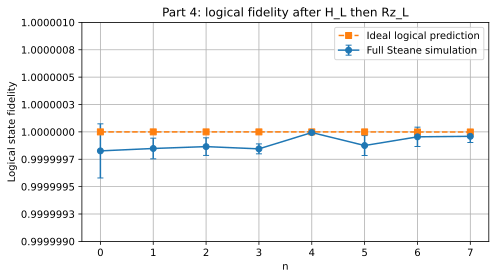

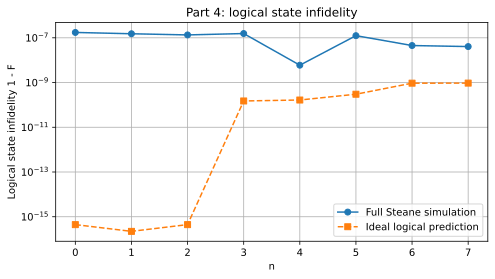

In [17]:
# ============================================================
# Part 4 - Logical-state fidelity on Steane [[7,1,3]]
# ============================================================

import os
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bloqade.pyqrack import StackMemorySimulator

sys.path.insert(0, os.getcwd())

import gate_syntesis_helpers as gh
import gate_syntesis

importlib.reload(gh)
importlib.reload(gate_syntesis)

from gate_syntesis import make_part4_logical_fidelity_kernel_reuse_magic


PART4_FIDELITY_N_VALUES = range(8)
PART4_FIDELITY_SHOTS = 5


def get_part4_sequence(n: int):
    if "part2_sequences" in globals() and n in part2_sequences:
        return tuple(part2_sequences[n])

    if "part2_rz_sequence" in globals():
        epsilon = globals().get("PART2_EPSILON", globals().get("EPSILON", 1e-4))
        return tuple(part2_rz_sequence(n, epsilon))

    raise NameError(
        "part2_sequences is not defined. Run the Part 2 sequence cell before this cell."
    )


def steane_basis_state(logical_bit: int):
    # Return |0_L> or |1_L> in the basis order used by reduced_density_matrix.
    psi = np.zeros(2**7, dtype=complex)

    for a in (0, 1):
        for b in (0, 1):
            for c in (0, 1):
                bits = [a, b, a ^ b, c, a ^ c, b ^ c, a ^ b ^ c]

                if logical_bit == 1:
                    bits = [bit ^ 1 for bit in bits]

                # PyQrack reduced_density_matrix uses big-endian matrix order
                # for the qubit list [q0, ..., q6].
                index = sum(bit << (6 - i) for i, bit in enumerate(bits))
                psi[index] += 1 / np.sqrt(8)

    return psi


ZERO_L = steane_basis_state(0)
ONE_L = steane_basis_state(1)


def target_logical_state_after_H_then_Rz(theta: float):
    return (
        np.exp(-0.5j * theta) * ZERO_L
        + np.exp(0.5j * theta) * ONE_L
    ) / np.sqrt(2)


def pure_state_fidelity_from_rho(rho, psi):
    value = np.vdot(psi, rho @ psi)
    return float(np.clip(np.real(value), 0.0, 1.0))


def ideal_logical_state_fidelity_from_sequence(theta: float, sequence):
    # Ideal logical-level prediction for the same synthesized Clifford+T sequence.
    psi0 = np.array([1, 0], dtype=complex)
    psi_after_h = gh.H @ psi0
    psi_target = gh.Rz(theta) @ psi_after_h
    psi_sequence = gh.unitary_from_gate_sequence(sequence) @ psi_after_h
    fidelity = abs(np.vdot(psi_target, psi_sequence)) ** 2
    return float(np.clip(np.real(fidelity), 0.0, 1.0))


rows = []

for n in PART4_FIDELITY_N_VALUES:
    theta = np.pi / (2**n)
    sequence = get_part4_sequence(n)
    t_count = gh.t_count_from_sequence(sequence)

    print(f"Simulating Part 4 n={n}, T-count={t_count}, shots={PART4_FIDELITY_SHOTS}")

    kernel = make_part4_logical_fidelity_kernel_reuse_magic(sequence)
    psi_target_logical = target_logical_state_after_H_then_Rz(theta)

    fidelities = []
    for _ in range(PART4_FIDELITY_SHOTS):
        sim = StackMemorySimulator(min_qubits=14)
        data_block = sim.run(kernel)
        rho_data = sim.reduced_density_matrix(data_block)
        fidelities.append(pure_state_fidelity_from_rho(rho_data, psi_target_logical))

    mean_fidelity = float(np.mean(fidelities))
    std_fidelity = float(np.std(fidelities))
    ideal_fidelity = ideal_logical_state_fidelity_from_sequence(theta, sequence)

    rows.append(
        {
            "n": n,
            "target": f"H_L then Rz_L(pi/2^{n})",
            "Rz_sequence": " ".join(sequence).upper(),
            "T_or_Tdg_count": t_count,
            "physical_qubits_simulated": 14,
            "shots": PART4_FIDELITY_SHOTS,
            "steane_state_fidelity_mean": mean_fidelity,
            "steane_state_fidelity_std": std_fidelity,
            "steane_state_infidelity_mean": max(0.0, 1.0 - mean_fidelity),
            "ideal_logical_state_fidelity": ideal_fidelity,
            "ideal_logical_state_infidelity": max(0.0, 1.0 - ideal_fidelity),
        }
    )


df_part4_logical_fidelity = pd.DataFrame(rows)
display(df_part4_logical_fidelity)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    df_part4_logical_fidelity["n"],
    df_part4_logical_fidelity["steane_state_fidelity_mean"],
    yerr=df_part4_logical_fidelity["steane_state_fidelity_std"],
    marker="o",
    capsize=3,
    label="Full Steane simulation",
)
ax.plot(
    df_part4_logical_fidelity["n"],
    df_part4_logical_fidelity["ideal_logical_state_fidelity"],
    marker="s",
    linestyle="--",
    label="Ideal logical prediction",
)
ax.set_xlabel("n")
ax.set_ylabel("Logical state fidelity")
ax.set_title("Part 4: logical fidelity after H_L then Rz_L")
ax.set_xticks(list(PART4_FIDELITY_N_VALUES))
ax.set_ylim(0.999999, 1.000001)
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.7f"))
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()

positive_steane_infidelity = df_part4_logical_fidelity["steane_state_infidelity_mean"].replace(0.0, np.nan)
positive_ideal_infidelity = df_part4_logical_fidelity["ideal_logical_state_infidelity"].replace(0.0, np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(
    df_part4_logical_fidelity["n"],
    positive_steane_infidelity,
    marker="o",
    label="Full Steane simulation",
)
ax.semilogy(
    df_part4_logical_fidelity["n"],
    positive_ideal_infidelity,
    marker="s",
    linestyle="--",
    label="Ideal logical prediction",
)
ax.set_xlabel("n")
ax.set_ylabel("Logical state infidelity 1 - F")
ax.set_title("Part 4: logical state infidelity")
ax.set_xticks(list(PART4_FIDELITY_N_VALUES))
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()


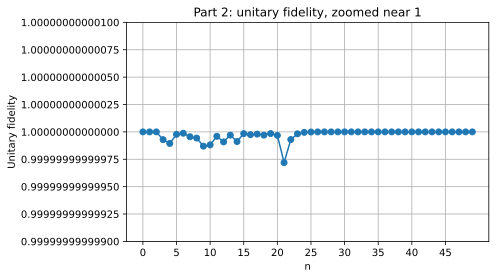

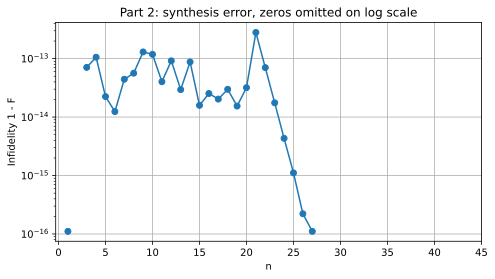

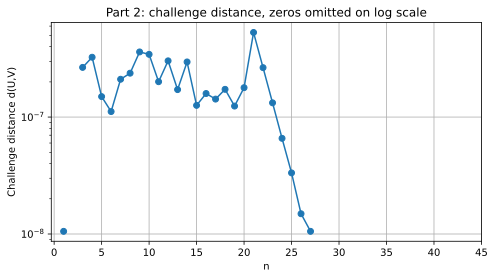

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from qiskit.synthesis import gridsynth_rz

import gate_syntesis_helpers as gh


EPSILON = 1e-6
N_VALUES = range(50)


def matrix_gate_distance(U, V):
    value = 1 - abs(np.trace(U.conj().T @ V)) / 2
    return np.sqrt(max(0.0, float(np.real(value))))


def safe_gridsynth_rz_sequence(theta: float, epsilon: float):
    target = gh.Rz(theta)

    # For coarse tolerances, the identity circuit can already be a valid
    # approximation. This also avoids a known gridsynth_rz panic at epsilon=1e-1.
    if matrix_gate_distance(target, gh.I) <= epsilon:
        return ()

    # If the Rust gridsynth backend panics for a coarse epsilon, retry with a
    # stricter tolerance. A stricter approximation is still valid for the
    # original epsilon.
    candidate_epsilons = [epsilon, 1e-3, 1e-4, 1e-6, 1e-10]
    tried = set()

    for eps_try in candidate_epsilons:
        if eps_try in tried or eps_try > epsilon:
            continue

        tried.add(eps_try)

        try:
            qiskit_circuit = gridsynth_rz(theta, epsilon=eps_try)
        except BaseException as exc:
            if type(exc).__name__ != "PanicException":
                raise
            continue

        sequence = gh.gate_sequence_from_circuit(qiskit_circuit)
        distance = matrix_gate_distance(target, gh.unitary_from_gate_sequence(sequence))

        if distance <= epsilon + 1e-15:
            return sequence

    raise RuntimeError(
        f"Could not synthesize Rz({theta}) within epsilon={epsilon} without gridsynth_rz failing."
    )


def part2_rz_sequence(n: int, epsilon: float = EPSILON):
    # Exact cases.
    if n == 0:
        return ("s", "s")   # Rz(pi) = Z = S^2 up to global phase

    if n == 1:
        return ("s",)       # Rz(pi/2) = S up to global phase

    if n == 2:
        return ("t",)       # Rz(pi/4) = T up to global phase

    # Approximate cases.
    theta = np.pi / (2 ** n)
    return safe_gridsynth_rz_sequence(theta, epsilon)


def unitary_fidelity(U, V):
    value = abs(np.trace(U.conj().T @ V)) / 2

    # The physical fidelity is in [0, 1]. Tiny excursions above 1 come only
    # from floating-point roundoff and make the plot look misleading.
    return float(np.clip(np.real(value), 0.0, 1.0))


def safe_gate_distance(U, V):
    fidelity = unitary_fidelity(U, V)
    value = max(0.0, 1.0 - fidelity)
    return np.sqrt(value)


def sparse_n_ticks(values, step=5):
    values = list(values)
    if len(values) <= 15:
        return values
    return values[::step]


def disable_y_offset(ax):
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(formatter)


rows = []

for n in N_VALUES:
    theta = np.pi / (2 ** n)

    sequence = part2_rz_sequence(n, EPSILON)

    U_target = gh.Rz(theta)
    V_circuit = gh.unitary_from_gate_sequence(sequence)

    fidelity = unitary_fidelity(U_target, V_circuit)
    distance = safe_gate_distance(U_target, V_circuit)
    infidelity = max(0.0, 1.0 - fidelity)

    rows.append(
        {
            "n": n,
            "target": f"Rz(pi/2^{n})",
            "theta": theta,
            "sequence": " ".join(sequence).upper(),
            "gate_count": len(sequence),
            "T_or_Tdg_count": gh.t_count_from_sequence(sequence),
            "unitary_fidelity": fidelity,
            "challenge_distance": distance,
            "infidelity": infidelity,
        }
    )


df_p2_fidelity = pd.DataFrame(rows)
#display(df_p2_fidelity)


plt.figure(figsize=(7, 4))
plt.plot(df_p2_fidelity["n"], df_p2_fidelity["unitary_fidelity"], marker="o")
plt.xlabel("n")
plt.ylabel("Unitary fidelity")
plt.title("Part 2: unitary fidelity, zoomed near 1")
plt.xticks(sparse_n_ticks(N_VALUES))
plt.ylim(0.999999999999, 1.000000000001)
disable_y_offset(plt.gca())
plt.grid(True)
plt.tight_layout()
plt.show()


positive_infidelity = df_p2_fidelity["infidelity"].replace(0.0, np.nan)

plt.figure(figsize=(7, 4))
plt.semilogy(df_p2_fidelity["n"], positive_infidelity, marker="o")
plt.xlabel("n")
plt.ylabel("Infidelity 1 - F")
plt.title("Part 2: synthesis error, zeros omitted on log scale")
plt.xticks(sparse_n_ticks(N_VALUES))
plt.grid(True)
plt.tight_layout()
plt.show()


positive_distance = df_p2_fidelity["challenge_distance"].replace(0.0, np.nan)

plt.figure(figsize=(7, 4))
plt.semilogy(df_p2_fidelity["n"], positive_distance, marker="o")
plt.xlabel("n")
plt.ylabel("Challenge distance d(U,V)")
plt.title("Part 2: challenge distance, zeros omitted on log scale")
plt.xticks(sparse_n_ticks(N_VALUES))
plt.grid(True)
plt.tight_layout()
plt.show()


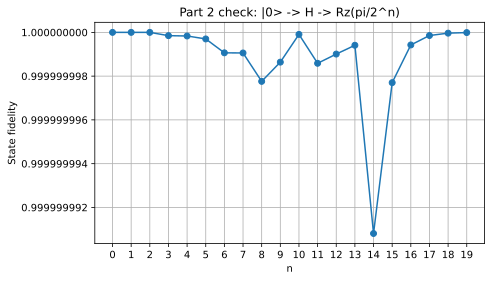

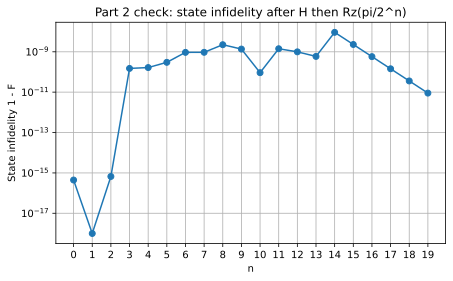

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit.synthesis import gridsynth_rz
from qiskit.quantum_info import Statevector, state_fidelity

import gate_syntesis_helpers as gh


EPSILON = 1e-4
N_VALUES = range(20)


def matrix_gate_distance(U, V):
    value = 1 - abs(np.trace(U.conj().T @ V)) / 2
    return np.sqrt(max(0.0, float(np.real(value))))


def safe_gridsynth_rz_sequence(theta: float, epsilon: float):
    target = gh.Rz(theta)

    # For coarse tolerances, the identity circuit can already be a valid
    # approximation. This also avoids a known gridsynth_rz panic at epsilon=1e-1.
    if matrix_gate_distance(target, gh.I) <= epsilon:
        return ()

    # If the Rust gridsynth backend panics for a coarse epsilon, retry with a
    # stricter tolerance. A stricter approximation is still valid for the
    # original epsilon.
    candidate_epsilons = [epsilon, 1e-3, 1e-4, 1e-6, 1e-10]
    tried = set()

    for eps_try in candidate_epsilons:
        if eps_try in tried or eps_try > epsilon:
            continue

        tried.add(eps_try)

        try:
            qiskit_circuit = gridsynth_rz(theta, epsilon=eps_try)
        except BaseException as exc:
            if type(exc).__name__ != "PanicException":
                raise
            continue

        sequence = gh.gate_sequence_from_circuit(qiskit_circuit)
        distance = matrix_gate_distance(target, gh.unitary_from_gate_sequence(sequence))

        if distance <= epsilon + 1e-15:
            return sequence

    raise RuntimeError(
        f"Could not synthesize Rz({theta}) within epsilon={epsilon} without gridsynth_rz failing."
    )


def part2_rz_sequence(n: int, epsilon: float = EPSILON):
    """
    Return the Clifford+T sequence used in Part 2 for Rz(pi/2^n).
    The first three cases are exact.
    """
    if n == 0:
        return ("s", "s")   # Rz(pi) = Z = S^2 up to global phase

    if n == 1:
        return ("s",)       # Rz(pi/2) = S up to global phase

    if n == 2:
        return ("t",)       # Rz(pi/4) = T up to global phase

    theta = np.pi / (2 ** n)
    return safe_gridsynth_rz_sequence(theta, epsilon)


psi0 = np.array([1, 0], dtype=complex)
psi_after_H = gh.H @ psi0

rows = []

for n in N_VALUES:
    theta = np.pi / (2 ** n)

    rz_sequence = part2_rz_sequence(n, EPSILON)

    U_target = gh.Rz(theta)
    V_synthesized = gh.unitary_from_gate_sequence(rz_sequence)

    psi_target = U_target @ psi_after_H
    psi_synthesized = V_synthesized @ psi_after_H

    fidelity = state_fidelity(
        Statevector(psi_target),
        Statevector(psi_synthesized),
    )

    rows.append(
        {
            "n": n,
            "target": f"H then Rz(pi/2^{n})",
            "part2_sequence_after_H": " ".join(("h",) + rz_sequence).upper(),
            "Rz_sequence": " ".join(rz_sequence).upper(),
            "T_or_Tdg_count": gh.t_count_from_sequence(rz_sequence),
            "state_fidelity": fidelity,
            "state_infidelity": 1 - fidelity,
        }
    )


df_H_then_Rz_state_fidelity = pd.DataFrame(rows)
#display(df_H_then_Rz_state_fidelity)


plt.figure(figsize=(7, 4))
plt.plot(
    df_H_then_Rz_state_fidelity["n"],
    df_H_then_Rz_state_fidelity["state_fidelity"],
    marker="o",
)
plt.xlabel("n")
plt.ylabel("State fidelity")
plt.title("Part 2 check: |0> -> H -> Rz(pi/2^n)")
plt.xticks(list(N_VALUES))
plt.grid(True)
plt.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.show()


plt.figure(figsize=(7, 4))
plt.semilogy(
    df_H_then_Rz_state_fidelity["n"],
    df_H_then_Rz_state_fidelity["state_infidelity"].clip(lower=1e-18),
    marker="o",
)
plt.xlabel("n")
plt.ylabel("State infidelity 1 - F")
plt.title("Part 2 check: state infidelity after H then Rz(pi/2^n)")
plt.xticks(list(N_VALUES))
plt.grid(True)
plt.show()
